In [4]:
from datetime import datetime, timedelta
import datetime as dt
import numpy as np
import pandas as pd
import xarray as xr
import os
import matplotlib.pyplot as plt

# use a small simulation as a test
fold = '/scratch/project_2018610/opendrift_outputs/first_tests/'
file = 'test_seeding_2500_every_third_day_region_1_2017_test.nc'
ds = xr.open_dataset(fold+file)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400


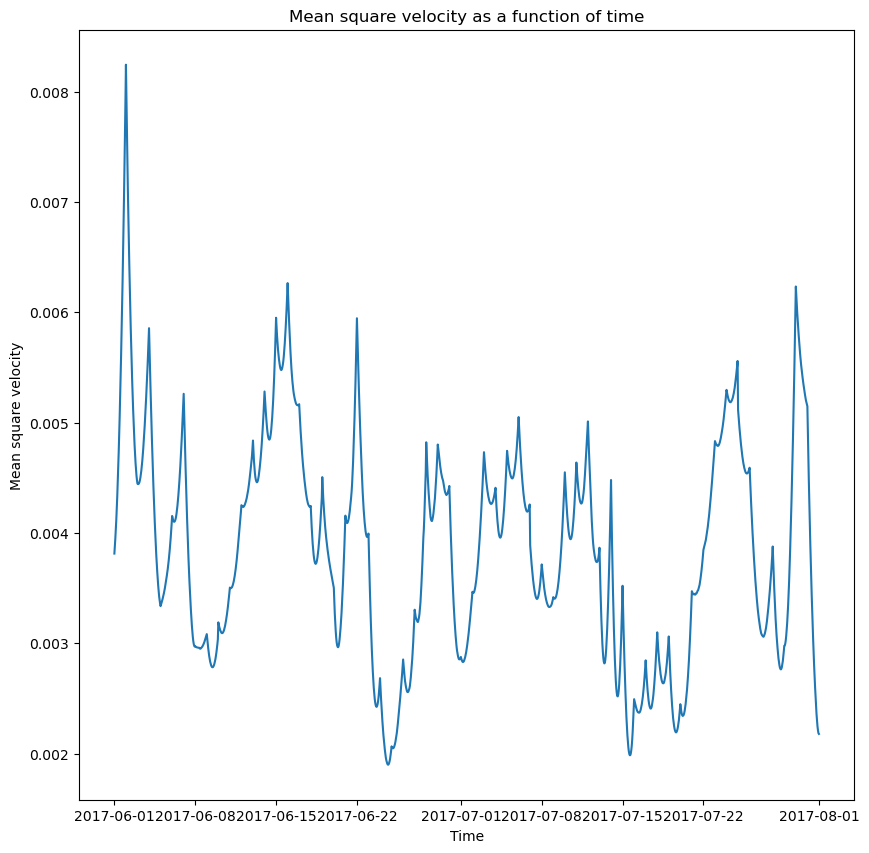

In [5]:
# written with the help of Claude
fig, ax = plt.subplots(figsize=(10, 10))

x_v = ds.x_sea_water_velocity
y_v = ds.y_sea_water_velocity

# Get dimension sizes
npart = x_v.sizes['trajectory']
nt = x_v.sizes['time']

mean_vel = np.zeros(nt)
# Take only upper triangle (unique pairs, exclude diagonal)
i, j = np.triu_indices(npart, k=1)

for t in range(nt):
    # if t%100==0 :
    #     print(t)
    # extract numpy arrays (avoid xarray indexing issues)
    x = x_v.isel(time=t).values  # shape: (npart,)
    y = y_v.isel(time=t).values
    
    # Create pairwise matrices
    speed_sqr = x**2 + y**2 
    A2 = speed_sqr[i]
    B2 = speed_sqr[j]
    AB = x[i]*x[j] + y[i]*y[j]

    # Mask pairs where either particle has NaN velocity
    valid = ~(np.isnan(A2) | np.isnan(B2) | np.isnan(AB))

    if valid.sum() > 0:
        mean_vel[t] = A2[valid].mean() + B2[valid].mean() - 2*AB[valid].mean()
    else:
        mean_vel[t] = np.nan  # whole timestep is bad

ax.plot(ds.time, mean_vel)
ax.set_title(f'Mean square velocity as a function of time')
ax.set_xlabel("Time")
ax.set_ylabel("Mean square velocity")
plt.show()
fig.savefig('test_velocity_correlation')

In [6]:
print(mean_vel)

[nan nan nan ... nan nan nan]
